# Comparative Analysis: 2025-11-07 vs 2025-11-19
## Dewar 1m - FBG and RTD Sensor Comparison

This notebook compares:
- FBG wavelength variations (Δλ vs time) between both days
- RTD temperature variations (ΔT vs time) between both days
- Sensitivity comparison (fm/mK)
- Inter-sensor offsets for FBG sensors

**Analysis focus**: Sensor 5 as reference

In [1]:
# ========================================================================
# Import Libraries
# ========================================================================

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import datetime
from matplotlib.dates import DateFormatter, MinuteLocator

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ========================================================================
# Load Data from Both Days
# ========================================================================

# --- Day 1: 2025-11-07 ---
file_07_11 = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(file_07_11) as f:
    peak_data_07 = f["peak"].arrays(library="np")
    temp_data_07 = f["temp"].arrays(library="np")

# --- Day 2: 2025-11-19 ---
file_19_11 = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"
with uproot.open(file_19_11) as f:
    peak_data_19 = f["peak"].arrays(library="np")
    temp_data_19 = f["temp"].arrays(library="np")

print("Data loaded successfully!")
print(f"07/11 - Peak entries: {len(peak_data_07['t'])}, Temp entries: {len(temp_data_07['t'])}")
print(f"19/11 - Peak entries: {len(peak_data_19['t'])}, Temp entries: {len(temp_data_19['t'])}")

Data loaded successfully!
07/11 - Peak entries: 2099000, Temp entries: 12490
19/11 - Peak entries: 7553875, Temp entries: 20554


In [3]:
# ========================================================================
# Process Day 1: 2025-11-07 (14:00 - 18:00)
# ========================================================================

sensor5_idx = 4  # 0-based index for sensor 5

# --- Extract Sensor 5 data ---
lambdaB_pol1_07 = peak_data_07["wav"][:, 0, sensor5_idx]
lambdaB_pol2_07 = peak_data_07["wav"][:, 1, sensor5_idx]
lambdaB_07 = (lambdaB_pol1_07 + lambdaB_pol2_07) / 2.0
temp_07 = temp_data_07["temp"][:, sensor5_idx]

# --- Timestamps with +2h correction for FBG ---
peak_times_07 = pd.to_datetime(peak_data_07["t"][:, 0], unit='s') + datetime.timedelta(hours=2)
temp_times_07 = pd.to_datetime(temp_data_07["t"], unit='s')

# --- Time window ---
start_07 = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_07 = datetime.datetime(2025, 11, 7, 18, 0, 0)

# --- Filter ---
mask_peak_07 = (peak_times_07 >= start_07) & (peak_times_07 <= end_07)
mask_temp_07 = (temp_times_07 >= start_07) & (temp_times_07 <= end_07)

# --- Create DataFrames ---
df_peak_07 = pd.DataFrame({
    "lambdaB_nm": lambdaB_07[mask_peak_07] * 1e9
}, index=peak_times_07[mask_peak_07])

df_temp_07 = pd.DataFrame({
    "temp_K": temp_07[mask_temp_07]
}, index=temp_times_07[mask_temp_07])

# --- Resample to 1-minute bins ---
peak_07_binned = df_peak_07.resample("1min").mean()
temp_07_binned = df_temp_07.resample("1min").mean()

# --- Convert to fm and mK ---
peak_07_binned["lambdaB_fm"] = peak_07_binned["lambdaB_nm"] * 1e6
temp_07_binned["temp_mK"] = temp_07_binned["temp_K"] * 1e3

# --- Calculate Δλ and ΔT (relative to first point) ---
lambda_ref_07 = peak_07_binned["lambdaB_fm"].iloc[0]
temp_ref_07 = temp_07_binned["temp_mK"].iloc[0]

peak_07_binned["delta_lambda_fm"] = peak_07_binned["lambdaB_fm"] - lambda_ref_07
temp_07_binned["delta_temp_mK"] = temp_07_binned["temp_mK"] - temp_ref_07

print(f"Day 07/11 processed: {len(peak_07_binned)} FBG points, {len(temp_07_binned)} RTD points")
print(f"  Δλ range: {peak_07_binned['delta_lambda_fm'].min():.2f} to {peak_07_binned['delta_lambda_fm'].max():.2f} fm")
print(f"  ΔT range: {temp_07_binned['delta_temp_mK'].min():.2f} to {temp_07_binned['delta_temp_mK'].max():.2f} mK")

Day 07/11 processed: 185 FBG points, 184 RTD points
  Δλ range: -4145.63 to 1530.99 fm
  ΔT range: -20.70 to 79.45 mK


In [4]:
# ========================================================================
# Process Day 2: 2025-11-19 (17:30 - 22:00)
# ========================================================================

# --- Extract Sensor 5 data ---
lambdaB_pol1_19 = peak_data_19["wav"][:, 0, sensor5_idx]
lambdaB_pol2_19 = peak_data_19["wav"][:, 1, sensor5_idx]
lambdaB_19 = (lambdaB_pol1_19 + lambdaB_pol2_19) / 2.0
temp_19 = temp_data_19["temp"][:, sensor5_idx]

# --- Timestamps with +2h correction for FBG ---
peak_times_19 = pd.to_datetime(peak_data_19["t"][:, 0], unit='s') + datetime.timedelta(hours=2)
temp_times_19 = pd.to_datetime(temp_data_19["t"], unit='s')

# --- Time window ---
start_19 = datetime.datetime(2025, 11, 19, 17, 30, 0)
end_19 = datetime.datetime(2025, 11, 19, 22, 0, 0)

# --- Filter ---
mask_peak_19 = (peak_times_19 >= start_19) & (peak_times_19 <= end_19)
mask_temp_19 = (temp_times_19 >= start_19) & (temp_times_19 <= end_19)

# --- Create DataFrames ---
df_peak_19 = pd.DataFrame({
    "lambdaB_nm": lambdaB_19[mask_peak_19] * 1e9
}, index=peak_times_19[mask_peak_19])

df_temp_19 = pd.DataFrame({
    "temp_K": temp_19[mask_temp_19]
}, index=temp_times_19[mask_temp_19])

# --- Resample to 1-minute bins ---
peak_19_binned = df_peak_19.resample("1min").mean()
temp_19_binned = df_temp_19.resample("1min").mean()

# --- Convert to fm and mK ---
peak_19_binned["lambdaB_fm"] = peak_19_binned["lambdaB_nm"] * 1e6
temp_19_binned["temp_mK"] = temp_19_binned["temp_K"] * 1e3

# --- Calculate Δλ and ΔT (relative to first point) ---
lambda_ref_19 = peak_19_binned["lambdaB_fm"].iloc[0]
temp_ref_19 = temp_19_binned["temp_mK"].iloc[0]

peak_19_binned["delta_lambda_fm"] = peak_19_binned["lambdaB_fm"] - lambda_ref_19
temp_19_binned["delta_temp_mK"] = temp_19_binned["temp_mK"] - temp_ref_19

print(f"Day 19/11 processed: {len(peak_19_binned)} FBG points, {len(temp_19_binned)} RTD points")
print(f"  Δλ range: {peak_19_binned['delta_lambda_fm'].min():.2f} to {peak_19_binned['delta_lambda_fm'].max():.2f} fm")
print(f"  ΔT range: {temp_19_binned['delta_temp_mK'].min():.2f} to {temp_19_binned['delta_temp_mK'].max():.2f} mK")

Day 19/11 processed: 270 FBG points, 270 RTD points
  Δλ range: -2707.89 to 223.92 fm
  ΔT range: -91.89 to 22.48 mK


In [5]:
# ========================================================================
# Create Relative Time Axis (minutes from start)
# ========================================================================

# Convert timestamps to minutes from start for easier comparison
peak_07_binned["minutes"] = (peak_07_binned.index - peak_07_binned.index[0]).total_seconds() / 60
temp_07_binned["minutes"] = (temp_07_binned.index - temp_07_binned.index[0]).total_seconds() / 60

peak_19_binned["minutes"] = (peak_19_binned.index - peak_19_binned.index[0]).total_seconds() / 60
temp_19_binned["minutes"] = (temp_19_binned.index - temp_19_binned.index[0]).total_seconds() / 60

print("Relative time axis created (minutes from start)")
print(f"  07/11: 0 to {peak_07_binned['minutes'].max():.1f} minutes")
print(f"  19/11: 0 to {peak_19_binned['minutes'].max():.1f} minutes")

Relative time axis created (minutes from start)
  07/11: 0 to 184.0 minutes
  19/11: 0 to 269.0 minutes


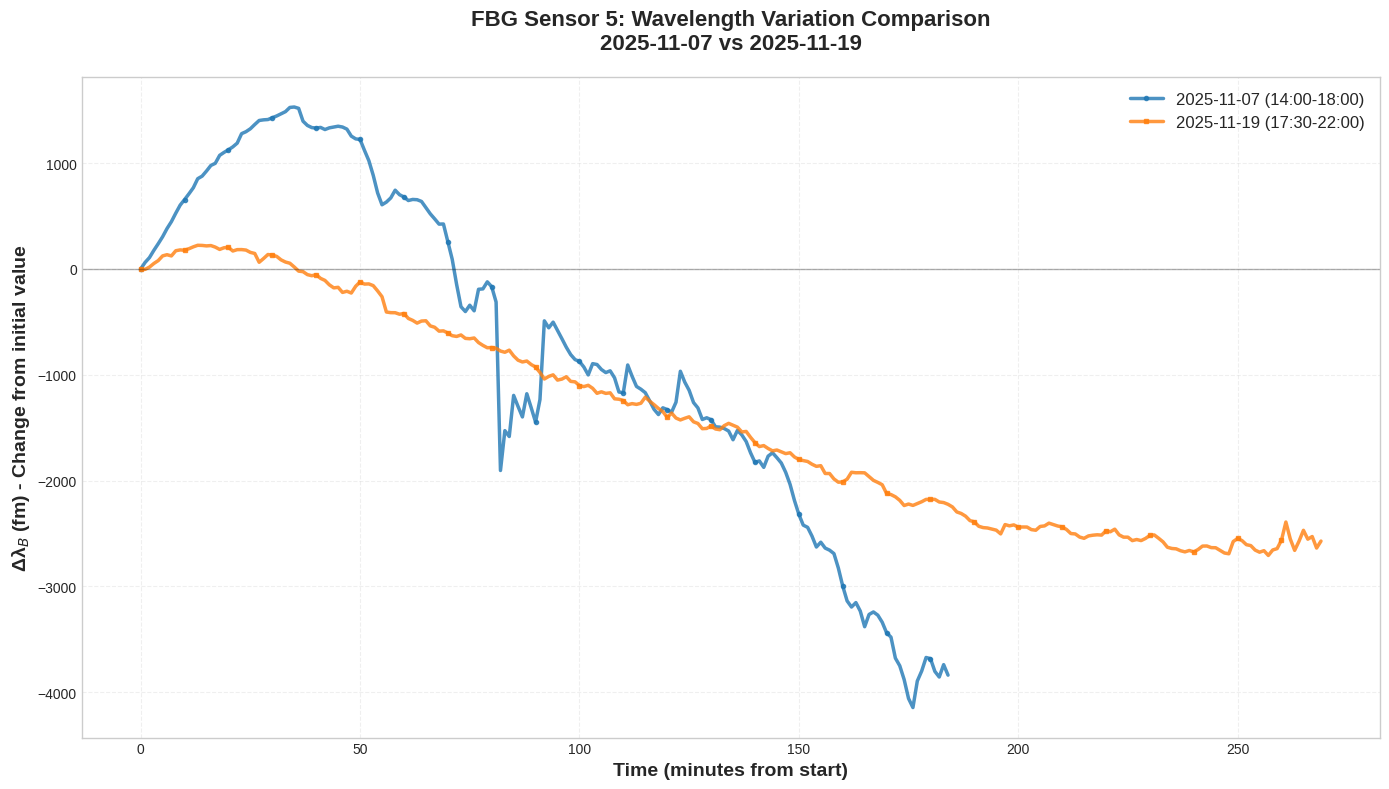

FBG WAVELENGTH VARIATION COMPARISON

07/11 (14:00-18:00):
  Total Δλ variation: 5676.62 fm
  Range: -4145.63 to 1530.99 fm

19/11 (17:30-22:00):
  Total Δλ variation: 2931.80 fm
  Range: -2707.89 to 223.92 fm


In [6]:
# ========================================================================
# COMPARATIVE PLOT 1: Δλ vs Time (Both Days)
# ========================================================================

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')

# --- Plot both days ---
ax.plot(peak_07_binned["minutes"], peak_07_binned["delta_lambda_fm"], 
        color='#1f77b4', linewidth=2.5, alpha=0.8, label='2025-11-07 (14:00-18:00)', marker='o', markersize=3, markevery=10)

ax.plot(peak_19_binned["minutes"], peak_19_binned["delta_lambda_fm"], 
        color='#ff7f0e', linewidth=2.5, alpha=0.8, label='2025-11-19 (17:30-22:00)', marker='s', markersize=3, markevery=10)

# --- Formatting ---
ax.set_xlabel('Time (minutes from start)', fontsize=14, fontweight='bold')
ax.set_ylabel('Δλ$_B$ (fm) - Change from initial value', fontsize=14, fontweight='bold')
ax.set_title('FBG Sensor 5: Wavelength Variation Comparison\n2025-11-07 vs 2025-11-19', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=12, loc='best', framealpha=0.95, edgecolor='black')
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Statistics ---
print("="*70)
print("FBG WAVELENGTH VARIATION COMPARISON")
print("="*70)
print(f"\n07/11 (14:00-18:00):")
print(f"  Total Δλ variation: {peak_07_binned['delta_lambda_fm'].max() - peak_07_binned['delta_lambda_fm'].min():.2f} fm")
print(f"  Range: {peak_07_binned['delta_lambda_fm'].min():.2f} to {peak_07_binned['delta_lambda_fm'].max():.2f} fm")

print(f"\n19/11 (17:30-22:00):")
print(f"  Total Δλ variation: {peak_19_binned['delta_lambda_fm'].max() - peak_19_binned['delta_lambda_fm'].min():.2f} fm")
print(f"  Range: {peak_19_binned['delta_lambda_fm'].min():.2f} to {peak_19_binned['delta_lambda_fm'].max():.2f} fm")
print("="*70)

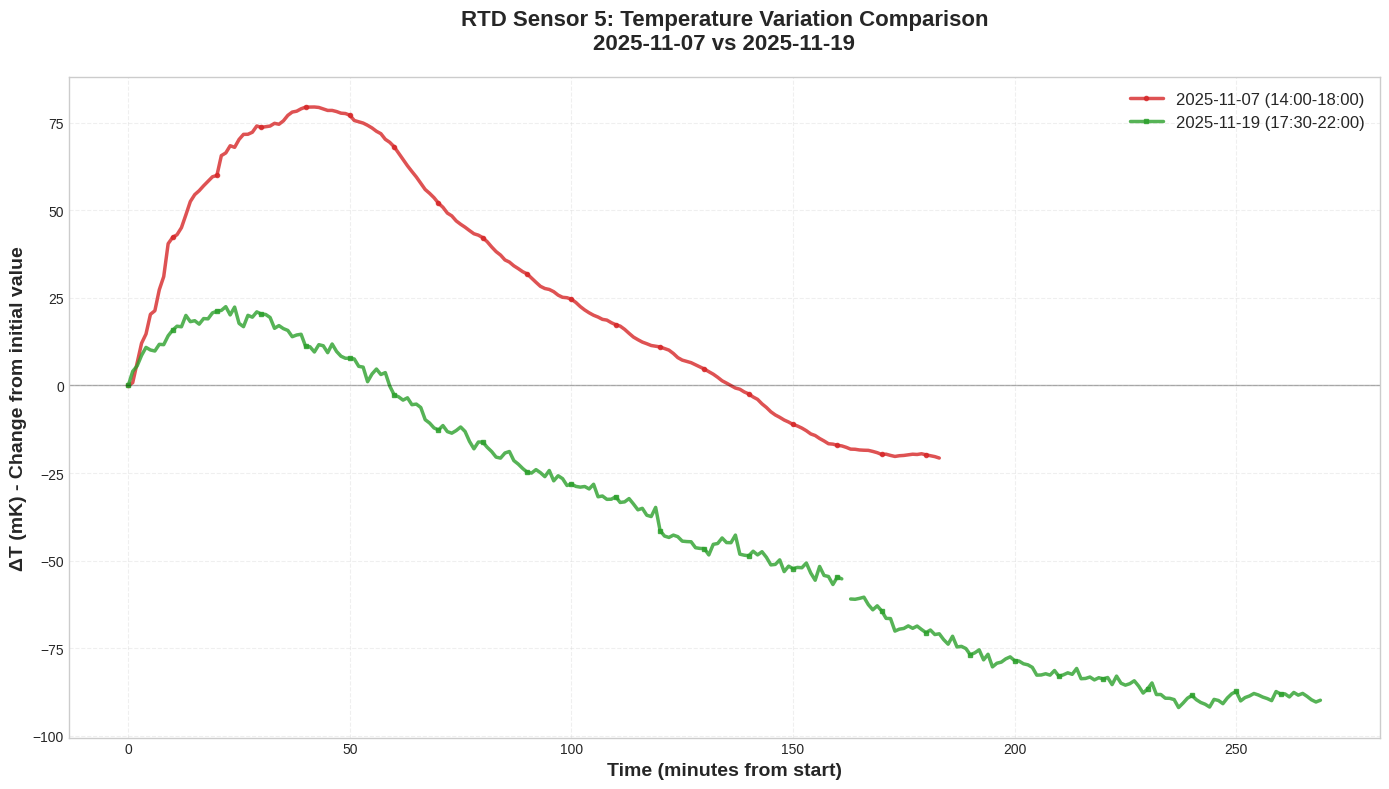

RTD TEMPERATURE VARIATION COMPARISON

07/11 (14:00-18:00):
  Total ΔT variation: 100.15 mK
  Range: -20.70 to 79.45 mK

19/11 (17:30-22:00):
  Total ΔT variation: 114.38 mK
  Range: -91.89 to 22.48 mK


In [7]:
# ========================================================================
# COMPARATIVE PLOT 2: ΔT vs Time (Both Days)
# ========================================================================

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')

# --- Plot both days ---
ax.plot(temp_07_binned["minutes"], temp_07_binned["delta_temp_mK"], 
        color='#d62728', linewidth=2.5, alpha=0.8, label='2025-11-07 (14:00-18:00)', marker='o', markersize=3, markevery=10)

ax.plot(temp_19_binned["minutes"], temp_19_binned["delta_temp_mK"], 
        color='#2ca02c', linewidth=2.5, alpha=0.8, label='2025-11-19 (17:30-22:00)', marker='s', markersize=3, markevery=10)

# --- Formatting ---
ax.set_xlabel('Time (minutes from start)', fontsize=14, fontweight='bold')
ax.set_ylabel('ΔT (mK) - Change from initial value', fontsize=14, fontweight='bold')
ax.set_title('RTD Sensor 5: Temperature Variation Comparison\n2025-11-07 vs 2025-11-19', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=12, loc='best', framealpha=0.95, edgecolor='black')
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Statistics ---
print("="*70)
print("RTD TEMPERATURE VARIATION COMPARISON")
print("="*70)
print(f"\n07/11 (14:00-18:00):")
print(f"  Total ΔT variation: {temp_07_binned['delta_temp_mK'].max() - temp_07_binned['delta_temp_mK'].min():.2f} mK")
print(f"  Range: {temp_07_binned['delta_temp_mK'].min():.2f} to {temp_07_binned['delta_temp_mK'].max():.2f} mK")

print(f"\n19/11 (17:30-22:00):")
print(f"  Total ΔT variation: {temp_19_binned['delta_temp_mK'].max() - temp_19_binned['delta_temp_mK'].min():.2f} mK")
print(f"  Range: {temp_19_binned['delta_temp_mK'].min():.2f} to {temp_19_binned['delta_temp_mK'].max():.2f} mK")
print("="*70)

In [21]:
# ========================================================================
# SENSITIVITY COMPARISON (fm/mK)
# ========================================================================

# Calculate sensitivity for each day using linear regression

def calculate_sensitivity(peak_df, temp_df):
    """Calculate sensitivity using manual linear regression with aligned data"""
    # Merge DataFrames on common time indices (inner join ensures alignment)
    combined = pd.merge(
        peak_df[["delta_lambda_fm"]], 
        temp_df[["delta_temp_mK"]], 
        left_index=True, 
        right_index=True, 
        how='inner'
    )
    
    # Extract aligned arrays
    lambda_data = combined["delta_lambda_fm"].values
    temp_data = combined["delta_temp_mK"].values
    
    # Remove NaN values
    valid_mask = ~(np.isnan(temp_data) | np.isnan(lambda_data))
    x = temp_data[valid_mask]
    y = lambda_data[valid_mask]
    
    if len(x) < 2:
        return 0.0, 0.0, 0
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean)**2)
    
    if denominator > 1e-6:
        slope = numerator / denominator
        intercept = y_mean - slope * x_mean
        
        # R-squared
        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y_mean)**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 1e-6 else 0.0
    else:
        slope = 0.0
        intercept = 0.0
        r_squared = 0.0
    
    return slope, intercept, r_squared, len(x)

# --- Day 07/11 ---
sens_07, intercept_07, r2_07, n_07 = calculate_sensitivity(peak_07_binned, temp_07_binned)

# --- Day 19/11 ---
sens_19, intercept_19, r2_19, n_19 = calculate_sensitivity(peak_19_binned, temp_19_binned)

print("="*70)
print("SENSITIVITY COMPARISON (Δλ/ΔT)")
print("="*70)
print(f"\n07/11 - Time window: 14:00-18:00 UTC (240 minutes)")
print(f"  Linear fit: Δλ = {sens_07:.2f} × ΔT + {intercept_07:.2f}")
print(f"  Sensitivity (slope): {sens_07:.2f} fm/mK")
print(f"  Intercept: {intercept_07:.2f} fm")
print(f"  R²: {r2_07:.4f}")
print(f"  Data points: {n_07}")

print(f"\n19/11 - Time window: 17:30-22:00 UTC (270 minutes)")
print(f"  Linear fit: Δλ = {sens_19:.2f} × ΔT + {intercept_19:.2f}")
print(f"  Sensitivity (slope): {sens_19:.2f} fm/mK")
print(f"  Intercept: {intercept_19:.2f} fm")
print(f"  R²: {r2_19:.4f}")
print(f"  Data points: {n_19}")

print(f"\nDifference:")
print(f"  Absolute: {abs(sens_07 - sens_19):.2f} fm/mK")
print(f"  Relative: {abs(sens_07 - sens_19) / max(sens_07, sens_19) * 100:.1f}%")
if sens_07 > sens_19:
    print(f"  → Day 07/11 has {(sens_07/sens_19 - 1)*100:.1f}% higher sensitivity")
else:
    print(f"  → Day 19/11 has {(sens_19/sens_07 - 1)*100:.1f}% higher sensitivity")
print("="*70)

SENSITIVITY COMPARISON (Δλ/ΔT)

07/11 - Time window: 14:00-18:00 UTC (240 minutes)
  Linear fit: Δλ = 44.48 × ΔT + -1974.77
  Sensitivity (slope): 44.48 fm/mK
  Intercept: -1974.77 fm
  R²: 0.8687
  Data points: 184

19/11 - Time window: 17:30-22:00 UTC (270 minutes)
  Linear fit: Δλ = 26.06 × ΔT + -344.43
  Sensitivity (slope): 26.06 fm/mK
  Intercept: -344.43 fm
  R²: 0.9927
  Data points: 269

Difference:
  Absolute: 18.42 fm/mK
  Relative: 41.4%
  → Day 07/11 has 70.7% higher sensitivity


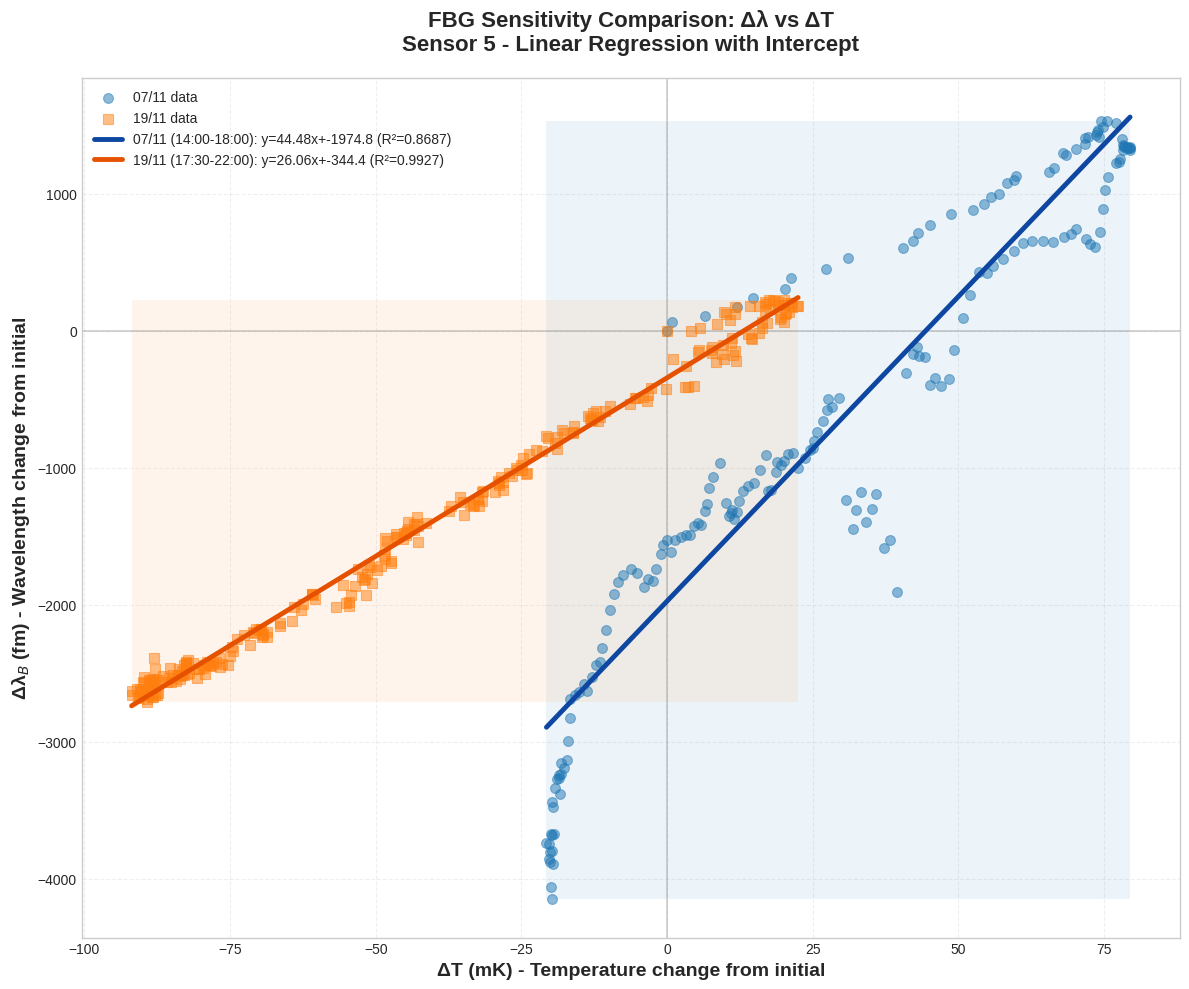

In [22]:
# ========================================================================
# COMPARATIVE PLOT 3: Δλ vs ΔT (Sensitivity Curves)
# ========================================================================

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('white')

# --- Align data for 07/11 (merge to ensure same indices) ---
combined_07 = pd.merge(
    peak_07_binned[["delta_lambda_fm"]], 
    temp_07_binned[["delta_temp_mK"]], 
    left_index=True, right_index=True, how='inner'
)

# --- Align data for 19/11 (merge to ensure same indices) ---
combined_19 = pd.merge(
    peak_19_binned[["delta_lambda_fm"]], 
    temp_19_binned[["delta_temp_mK"]], 
    left_index=True, right_index=True, how='inner'
)

# --- Scatter plots with aligned data ---
ax.scatter(combined_07["delta_temp_mK"], combined_07["delta_lambda_fm"],
          color='#1f77b4', s=50, alpha=0.5, label='07/11 data', edgecolors='#1f77b4', linewidth=0.8, zorder=2)

ax.scatter(combined_19["delta_temp_mK"], combined_19["delta_lambda_fm"],
          color='#ff7f0e', s=50, alpha=0.5, label='19/11 data', marker='s', edgecolors='#ff7f0e', linewidth=0.8, zorder=2)

# --- Linear fit lines WITH INTERCEPT (y = slope*x + intercept) ---
if sens_07 != 0:
    x_fit_07 = np.linspace(combined_07["delta_temp_mK"].min(), combined_07["delta_temp_mK"].max(), 100)
    y_fit_07 = sens_07 * x_fit_07 + intercept_07  # Now includes intercept!
    ax.plot(x_fit_07, y_fit_07, '-', color='#0d47a1', linewidth=3.5, 
            label=f'07/11 (14:00-18:00): y={sens_07:.2f}x+{intercept_07:.1f} (R²={r2_07:.4f})', zorder=3)

if sens_19 != 0:
    x_fit_19 = np.linspace(combined_19["delta_temp_mK"].min(), combined_19["delta_temp_mK"].max(), 100)
    y_fit_19 = sens_19 * x_fit_19 + intercept_19  # Now includes intercept!
    ax.plot(x_fit_19, y_fit_19, '-', color='#e65100', linewidth=3.5, 
            label=f'19/11 (17:30-22:00): y={sens_19:.2f}x+{intercept_19:.1f} (R²={r2_19:.4f})', zorder=3)

# --- Add data range indicators ---
# Show the actual data spread with semi-transparent bands
from matplotlib.patches import Rectangle
data_range_07 = Rectangle((combined_07["delta_temp_mK"].min(), combined_07["delta_lambda_fm"].min()),
                          combined_07["delta_temp_mK"].max() - combined_07["delta_temp_mK"].min(),
                          combined_07["delta_lambda_fm"].max() - combined_07["delta_lambda_fm"].min(),
                          alpha=0.08, facecolor='#1f77b4', edgecolor='none', zorder=1)
data_range_19 = Rectangle((combined_19["delta_temp_mK"].min(), combined_19["delta_lambda_fm"].min()),
                          combined_19["delta_temp_mK"].max() - combined_19["delta_temp_mK"].min(),
                          combined_19["delta_lambda_fm"].max() - combined_19["delta_lambda_fm"].min(),
                          alpha=0.08, facecolor='#ff7f0e', edgecolor='none', zorder=1)
ax.add_patch(data_range_07)
ax.add_patch(data_range_19)

# --- Formatting ---
ax.set_xlabel('ΔT (mK) - Temperature change from initial', fontsize=14, fontweight='bold')
ax.set_ylabel('Δλ$_B$ (fm) - Wavelength change from initial', fontsize=14, fontweight='bold')
ax.set_title('FBG Sensitivity Comparison: Δλ vs ΔT\nSensor 5 - Linear Regression with Intercept', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, zorder=0)
ax.legend(fontsize=10, loc='best', framealpha=0.98, edgecolor='black', fancybox=True, shadow=True)
ax.axhline(0, color='gray', linestyle='-', linewidth=1.2, alpha=0.4, zorder=1)
ax.axvline(0, color='gray', linestyle='-', linewidth=1.2, alpha=0.4, zorder=1)

plt.tight_layout()
plt.show()

In [20]:
# ========================================================================
# INTER-SENSOR OFFSETS: Load All FBG Sensors for Both Days
# ========================================================================

def load_all_sensors_fbg(peak_data, start_time, end_time):
    """Load and process all FBG sensors"""
    
    # Extract timestamps
    peak_times = pd.to_datetime(peak_data["t"][:, 0], unit='s') + datetime.timedelta(hours=2)
    mask = (peak_times >= start_time) & (peak_times <= end_time)
    
    sensors_data = {}
    
    for sensor_idx in range(5):  # Sensors 0-4 (1-5 in physical numbering)
        sensor_name = f"sensor{sensor_idx+1}"
        
        # Average over polarizations
        lambdaB_pol1 = peak_data["wav"][:, 0, sensor_idx]
        lambdaB_pol2 = peak_data["wav"][:, 1, sensor_idx]
        lambdaB = (lambdaB_pol1 + lambdaB_pol2) / 2.0
        
        # Create DataFrame
        df = pd.DataFrame({
            "lambdaB_nm": lambdaB[mask] * 1e9
        }, index=peak_times[mask])
        
        # Resample
        df_binned = df.resample("1min").mean()
        df_binned["lambdaB_fm"] = df_binned["lambdaB_nm"] * 1e6
        
        sensors_data[sensor_name] = df_binned
    
    return sensors_data

# --- Load all sensors for 07/11 ---
sensors_07 = load_all_sensors_fbg(peak_data_07, start_07, end_07)
print(f"Day 07/11: Loaded {len(sensors_07)} FBG sensors")

# --- Load all sensors for 19/11 ---
sensors_19 = load_all_sensors_fbg(peak_data_19, start_19, end_19)
print(f"Day 19/11: Loaded {len(sensors_19)} FBG sensors")

Day 07/11: Loaded 5 FBG sensors
Day 19/11: Loaded 5 FBG sensors
Day 19/11: Loaded 5 FBG sensors


In [13]:
# ========================================================================
# CALCULATE OFFSETS (all sensors relative to Sensor 5)
# ========================================================================

def calculate_offsets(sensors_data, reference_sensor="sensor5"):
    """Calculate offsets relative to reference sensor"""
    
    ref_data = sensors_data[reference_sensor]["lambdaB_fm"]
    offsets = {}
    
    for sensor_name, sensor_df in sensors_data.items():
        if sensor_name != reference_sensor:
            # Calculate offset: sensor - reference
            offset = sensor_df["lambdaB_fm"] - ref_data
            offsets[sensor_name] = offset
    
    # Combine into single DataFrame
    df_offsets = pd.DataFrame(offsets)
    return df_offsets

# --- Calculate offsets ---
offsets_07 = calculate_offsets(sensors_07)
offsets_19 = calculate_offsets(sensors_19)

print("\n" + "="*70)
print("FBG INTER-SENSOR OFFSETS (relative to Sensor 5)")
print("="*70)

print("\n07/11 - Mean offsets (fm):")
for col in offsets_07.columns:
    mean_val = offsets_07[col].mean()
    std_val = offsets_07[col].std()
    print(f"  {col}: {mean_val:>8.2f} ± {std_val:.2f} fm")

print("\n19/11 - Mean offsets (fm):")
for col in offsets_19.columns:
    mean_val = offsets_19[col].mean()
    std_val = offsets_19[col].std()
    print(f"  {col}: {mean_val:>8.2f} ± {std_val:.2f} fm")

print("="*70)


FBG INTER-SENSOR OFFSETS (relative to Sensor 5)

07/11 - Mean offsets (fm):
  sensor1: -23636843.41 ± 1013.63 fm
  sensor2: -17703049.03 ± 295.41 fm
  sensor3: -11798436.58 ± 303.11 fm
  sensor4: -5862389.20 ± 353.45 fm

19/11 - Mean offsets (fm):
  sensor1: -23638932.99 ± 1470.74 fm
  sensor2: -17524754.75 ± 1139.44 fm
  sensor3: -11590962.95 ± 238.79 fm
  sensor4: -5763806.49 ± 91.36 fm


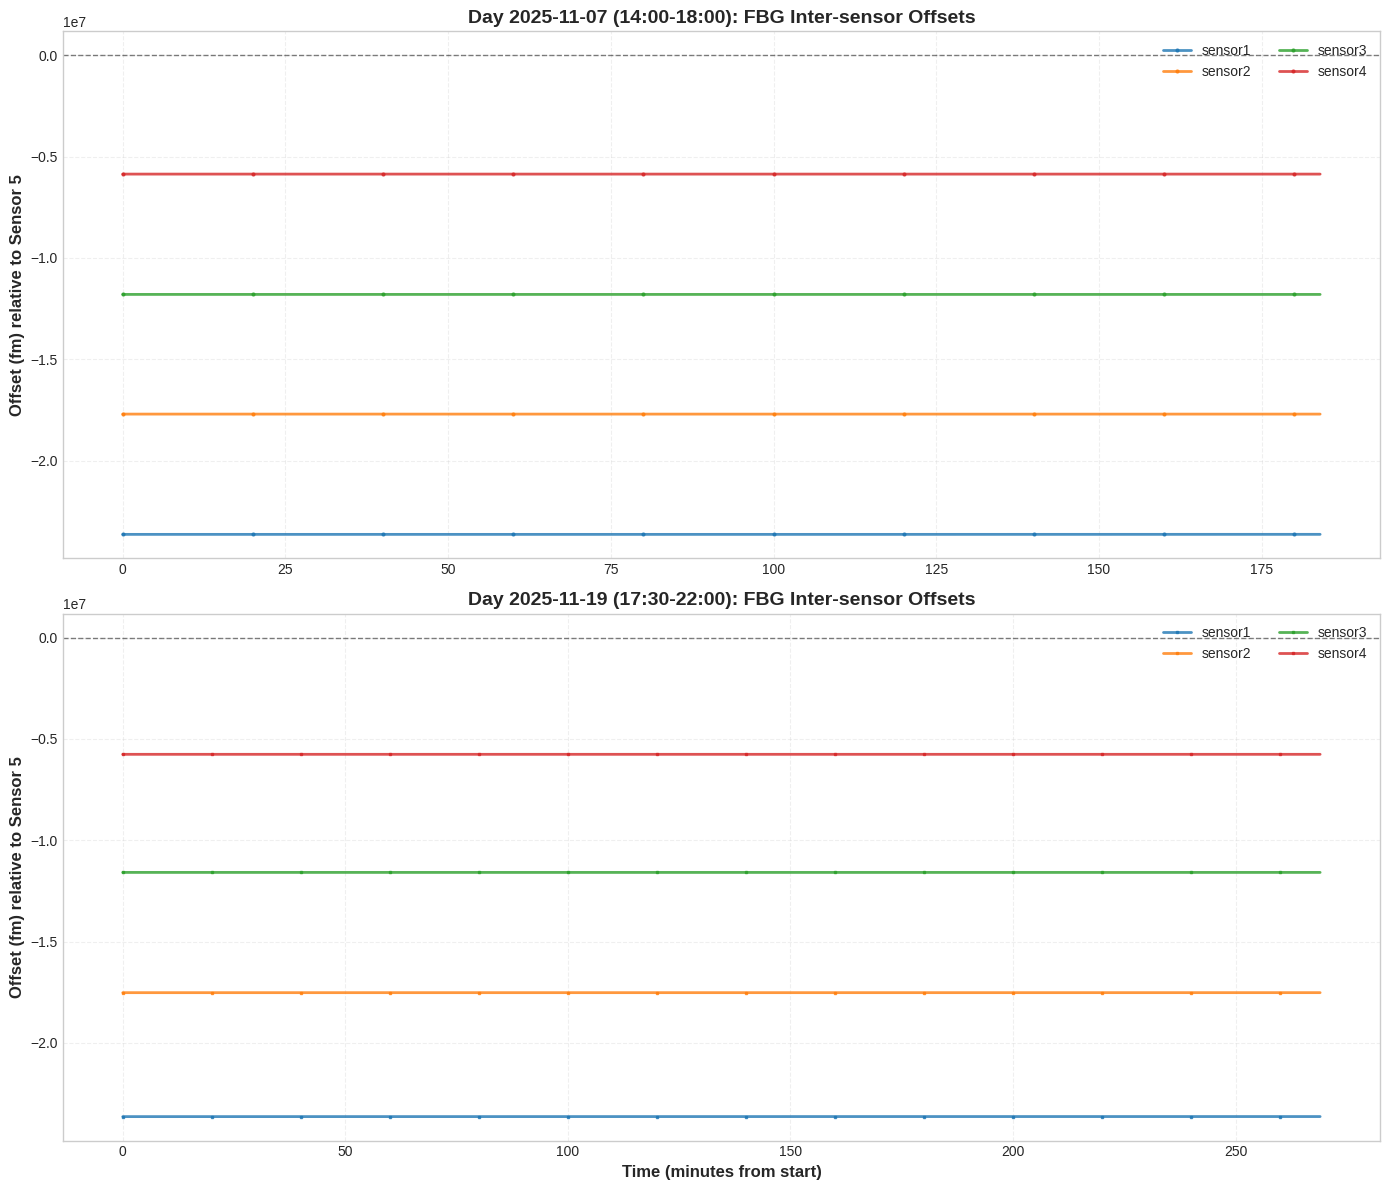

In [14]:
# ========================================================================
# COMPARATIVE PLOT 4: Inter-sensor Offsets
# ========================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)
fig.patch.set_facecolor('white')

# --- Calculate time axis ONCE for each day (outside the loop) ---
minutes_07 = (offsets_07.index - offsets_07.index[0]).total_seconds() / 60
minutes_19 = (offsets_19.index - offsets_19.index[0]).total_seconds() / 60

# --- Day 07/11 ---
for col in offsets_07.columns:
    ax1.plot(minutes_07, offsets_07[col], linewidth=2, alpha=0.8, label=col, marker='o', markersize=2, markevery=20)

ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_ylabel('Offset (fm) relative to Sensor 5', fontsize=12, fontweight='bold')
ax1.set_title('Day 2025-11-07 (14:00-18:00): FBG Inter-sensor Offsets', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax1.legend(fontsize=10, loc='best', ncol=2)

# --- Day 19/11 ---
for col in offsets_19.columns:
    ax2.plot(minutes_19, offsets_19[col], linewidth=2, alpha=0.8, label=col, marker='s', markersize=2, markevery=20)

ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Time (minutes from start)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Offset (fm) relative to Sensor 5', fontsize=12, fontweight='bold')
ax2.set_title('Day 2025-11-19 (17:30-22:00): FBG Inter-sensor Offsets', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax2.legend(fontsize=10, loc='best', ncol=2)

plt.tight_layout()
plt.show()

In [15]:
# ========================================================================
# FINAL SUMMARY TABLE
# ========================================================================

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON SUMMARY: 2025-11-07 vs 2025-11-19")
print("="*80)

print("\n1. WAVELENGTH VARIATION (Δλ):")
print("-" * 80)
print(f"{'Metric':<40} {'07/11':>15} {'19/11':>15}")
print("-" * 80)
delta_lambda_07 = peak_07_binned['delta_lambda_fm'].max() - peak_07_binned['delta_lambda_fm'].min()
delta_lambda_19 = peak_19_binned['delta_lambda_fm'].max() - peak_19_binned['delta_lambda_fm'].min()
print(f"{'Total Δλ variation (fm)':<40} {delta_lambda_07:>15.2f} {delta_lambda_19:>15.2f}")
print(f"{'Max Δλ (fm)':<40} {peak_07_binned['delta_lambda_fm'].max():>15.2f} {peak_19_binned['delta_lambda_fm'].max():>15.2f}")
print(f"{'Min Δλ (fm)':<40} {peak_07_binned['delta_lambda_fm'].min():>15.2f} {peak_19_binned['delta_lambda_fm'].min():>15.2f}")

print("\n2. TEMPERATURE VARIATION (ΔT):")
print("-" * 80)
print(f"{'Metric':<40} {'07/11':>15} {'19/11':>15}")
print("-" * 80)
delta_temp_07 = temp_07_binned['delta_temp_mK'].max() - temp_07_binned['delta_temp_mK'].min()
delta_temp_19 = temp_19_binned['delta_temp_mK'].max() - temp_19_binned['delta_temp_mK'].min()
print(f"{'Total ΔT variation (mK)':<40} {delta_temp_07:>15.2f} {delta_temp_19:>15.2f}")
print(f"{'Max ΔT (mK)':<40} {temp_07_binned['delta_temp_mK'].max():>15.2f} {temp_19_binned['delta_temp_mK'].max():>15.2f}")
print(f"{'Min ΔT (mK)':<40} {temp_07_binned['delta_temp_mK'].min():>15.2f} {temp_19_binned['delta_temp_mK'].min():>15.2f}")

print("\n3. SENSITIVITY (Δλ/ΔT):")
print("-" * 80)
print(f"{'Metric':<40} {'07/11':>15} {'19/11':>15}")
print("-" * 80)
print(f"{'Sensitivity (fm/mK)':<40} {sens_07:>15.2f} {sens_19:>15.2f}")
print(f"{'R² (correlation quality)':<40} {r2_07:>15.4f} {r2_19:>15.4f}")
print(f"{'Data points used':<40} {n_07:>15d} {n_19:>15d}")
print(f"\nSensitivity difference: {abs(sens_07 - sens_19):.2f} fm/mK ({abs(sens_07-sens_19)/max(sens_07,sens_19)*100:.1f}%)")

print("\n4. INTER-SENSOR OFFSETS (mean ± std, fm):")
print("-" * 80)
print(f"{'Sensor':<15} {'07/11 Mean':>15} {'07/11 Std':>12} {'19/11 Mean':>15} {'19/11 Std':>12}")
print("-" * 80)
for col in offsets_07.columns:
    mean_07 = offsets_07[col].mean()
    std_07 = offsets_07[col].std()
    mean_19 = offsets_19[col].mean()
    std_19 = offsets_19[col].std()
    print(f"{col:<15} {mean_07:>15.2f} {std_07:>12.2f} {mean_19:>15.2f} {std_19:>12.2f}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


COMPREHENSIVE COMPARISON SUMMARY: 2025-11-07 vs 2025-11-19

1. WAVELENGTH VARIATION (Δλ):
--------------------------------------------------------------------------------
Metric                                             07/11           19/11
--------------------------------------------------------------------------------
Total Δλ variation (fm)                          5676.62         2931.80
Max Δλ (fm)                                      1530.99          223.92
Min Δλ (fm)                                     -4145.63        -2707.89

2. TEMPERATURE VARIATION (ΔT):
--------------------------------------------------------------------------------
Metric                                             07/11           19/11
--------------------------------------------------------------------------------
Total ΔT variation (mK)                           100.15          114.38
Max ΔT (mK)                                        79.45           22.48
Min ΔT (mK)                               